# 第7回 勉強会 (1) — 感情分析データの EDA とラベル構造

教科書 chapter05 のノートが冒頭でやっている「**データ構造の確認**」「**ラベル分布**」
「**テキスト長の分布**」を、今回のデータで**圧縮版**として再現します。

- **データ**: `McAuley-Lab/Amazon-Reviews-2023`（All_Beauty, 英語）
- **タスク**: レビュー本文 → 感情（positive / negative）の二値分類
- **ラベルの作り方**: 教科書 MARC-ja と同じく **星4-5→positive / 星1-2→negative / 星3は除外**
- **狙い**: 教科書が MARC-ja で語る「**不均衡データ**」を体験する（このデータは positive 偏重）

学習はしません。データを「見る」だけのノートです（CPUで動きます）。

In [1]:
import json
from collections import Counter

import japanize_matplotlib  # noqa: F401  日本語フォント有効化
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download

%matplotlib inline
plt.rcParams["font.size"] = 12

/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. データ構造を見る

まずは生のレビュー1件を表示し、どんなフィールドがあるかを確認します。
（全70万件は多いので、先頭 5万件だけ読み込みます）

In [2]:
path = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename="raw/review_categories/All_Beauty.jsonl",
    repo_type="dataset",
)

records = []
with open(path) as f:
    for i, line in enumerate(f):
        if i >= 50000:
            break
        records.append(json.loads(line))

print("読み込み件数:", len(records))
print("フィールド:", list(records[0].keys()))
records[0]

読み込み件数: 50000
フィールド: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


{'rating': 5.0,
 'title': 'Such a lovely scent but not overpowering.',
 'text': "This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!",
 'images': [],
 'asin': 'B00YQ6X8EO',
 'parent_asin': 'B00YQ6X8EO',
 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ',
 'timestamp': 1588687728923,
 'helpful_vote': 0,
 'verified_purchase': True}

感情分析に使うのは **`text`（レビュー本文）** と **`rating`（星評価 1〜5）** の2つです。
`rating` を手がかりに感情ラベルを作ります。

## 2. 星評価（rating）の分布

ラベルの「素」になる星評価の分布を見ます。ここに**偏り**があると、作るラベルも偏ります。

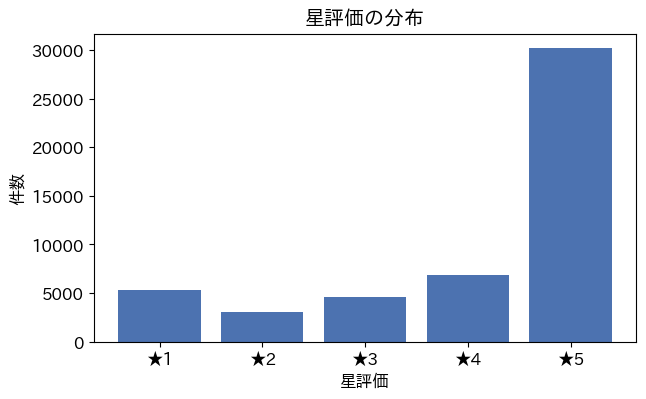

★1:   5355  (10.7%)
★2:   3013  (6.0%)
★3:   4598  (9.2%)
★4:   6874  (13.7%)
★5:  30160  (60.3%)


In [3]:
ratings = Counter(r["rating"] for r in records)
xs = sorted(ratings)

plt.figure(figsize=(7, 4))
plt.bar([f"★{int(x)}" for x in xs], [ratings[x] for x in xs], color="#4c72b0")
plt.xlabel("星評価")
plt.ylabel("件数")
plt.title("星評価の分布")
plt.show()

for x in xs:
    print(f"★{int(x)}: {ratings[x]:>6d}  ({ratings[x] / len(records):.1%})")

**★5 が圧倒的に多い**のが分かります。レビューは「満足した人」が書きがちなので、
高評価に偏るのは現実のデータでよくある傾向です。

## 3. 星 → 二値ラベル（教科書 MARC-ja と同じ方針）

- 星 **4, 5** → `positive`
- 星 **1, 2** → `negative`
- 星 **3**（中立）→ **除外**

In [4]:
texts, labels = [], []
for r in records:
    rating = r["rating"]
    text = (r.get("text") or "").strip()
    if not text:
        continue
    if rating >= 4:
        labels.append("positive")
    elif rating <= 2:
        labels.append("negative")
    else:
        continue  # 星3は除外
    texts.append(text)

label_counts = Counter(labels)
pos, neg = label_counts["positive"], label_counts["negative"]
total = pos + neg
print(f"positive: {pos}")
print(f"negative: {neg}")
print(f"positive率: {pos / total:.1%}")

positive: 37029
negative: 8366
positive率: 81.6%


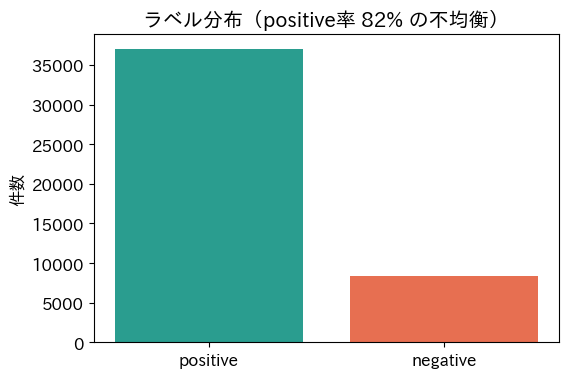

In [5]:
plt.figure(figsize=(6, 4))
plt.bar(["positive", "negative"], [pos, neg], color=["#2a9d8f", "#e76f51"])
plt.ylabel("件数")
plt.title(f"ラベル分布（positive率 {pos / total:.0%} の不均衡）")
plt.show()

**多数派 positive に大きく偏った不均衡データ**になりました。
これが教科書の言う「不均衡データ」です。
→ このまま学習・評価すると **「正解率の罠」** にはまります（ノート2で扱います）。

## 4. テキスト長の分布（ラベル別）

positive と negative で、文の長さに違いはあるでしょうか？

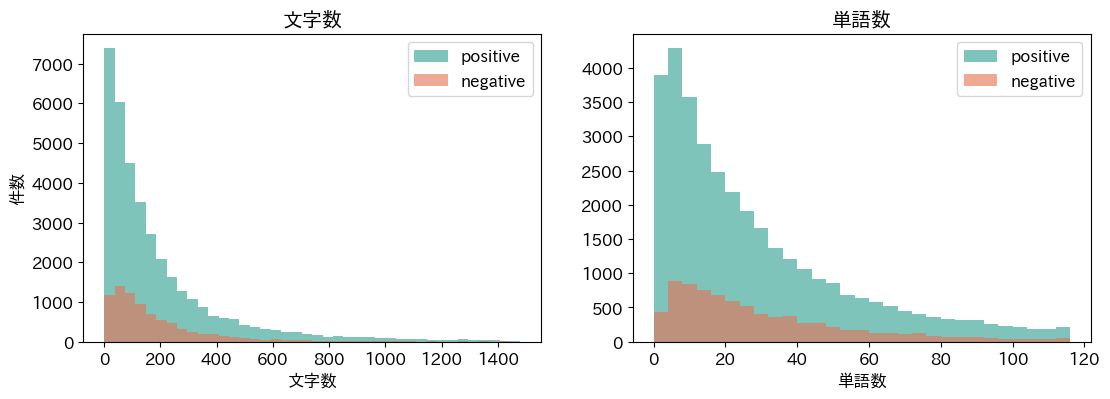

positive: 平均文字数 220 / 平均単語数 41
negative: 平均文字数 193 / 平均単語数 37


In [6]:
char_len = {"positive": [], "negative": []}
word_len = {"positive": [], "negative": []}
for text, label in zip(texts, labels):
    char_len[label].append(len(text))
    word_len[label].append(len(text.split()))

all_chars = char_len["positive"] + char_len["negative"]
cap = int(np.percentile(all_chars, 99))  # 外れ値で潰れないよう99%点まで

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, color in [("positive", "#2a9d8f"), ("negative", "#e76f51")]:
    axes[0].hist(char_len[label], bins=np.arange(0, cap, cap // 40),
                 alpha=0.6, label=label, color=color)
    axes[1].hist(word_len[label], bins=np.arange(0, 120, 4),
                 alpha=0.6, label=label, color=color)
axes[0].set_title("文字数")
axes[0].set_xlabel("文字数")
axes[0].set_ylabel("件数")
axes[0].legend()
axes[1].set_title("単語数")
axes[1].set_xlabel("単語数")
axes[1].legend()
plt.show()

for label in ["positive", "negative"]:
    print(f"{label}: 平均文字数 {np.mean(char_len[label]):.0f} / "
          f"平均単語数 {np.mean(word_len[label]):.0f}")

一般に **negative の方がやや長くなりがち**（不満は説明が長くなる）。
データによって傾向は違うので、必ず自分のデータで確認するのが EDA の基本です。

## 5. ラベルを特徴づける語（簡易版）

positive / negative それぞれで、どんな単語がよく出るかを見ます
（記号を落とし、ごく一般的な語＝ストップワードは除外した簡易集計）。

In [7]:
STOP = set(
    "the a an and or to of in is it i this that for on was with my you have "
    "but not so very as be are at me too if all just then we they he she "
    "of's t s m re ve d ll our your their its had has".split()
)


def tokenize_en(text: str):
    return [w.strip(".,!?\"'()[]:;").lower() for w in text.split()]


freq = {"positive": Counter(), "negative": Counter()}
for text, label in zip(texts, labels):
    for w in tokenize_en(text):
        if len(w) > 2 and w not in STOP:
            freq[label][w] += 1

for label in ["positive", "negative"]:
    print(f"{label}: ", [w for w, _ in freq[label].most_common(15)])

positive:  ['hair', 'great', 'use', 'love', 'like', 'these', 'product', 'good', 'skin', 'one', 'them', 'well', '/><br', 'really', 'will']
negative:  ['hair', 'like', 'product', 'these', 'use', 'one', 'out', 'would', 'them', 'get', 'work', 'off', 'when', 'did', 'even']


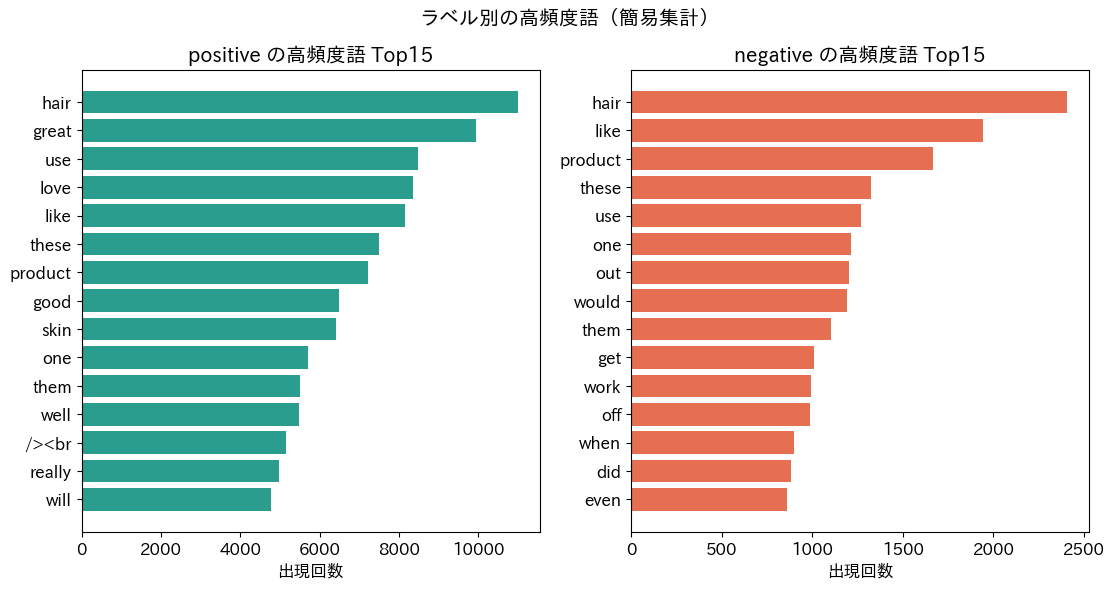

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, label, color in [
    (axes[0], "positive", "#2a9d8f"), (axes[1], "negative", "#e76f51")
]:
    top = freq[label].most_common(15)[::-1]
    ax.barh([w for w, _ in top], [c for _, c in top], color=color)
    ax.set_title(f"{label} の高頻度語 Top15")
    ax.set_xlabel("出現回数")
fig.suptitle("ラベル別の高頻度語（簡易集計）")
plt.show()

## 6. サンプル事例

In [9]:
shown = {"positive": 0, "negative": 0}
for text, label in zip(texts, labels):
    if shown[label] < 3:
        print(f"[{label}] {text[:150]}")
        print("-" * 60)
        shown[label] += 1
    if all(v >= 3 for v in shown.values()):
        break

[positive] This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get
------------------------------------------------------------
[positive] This product does what I need it to do, I just wish it was odorless or had a soft coconut smell. Having my head smell like an orange coffee is offputt
------------------------------------------------------------
[positive] Smells good, feels great!
------------------------------------------------------------
[negative] Felt synthetic
------------------------------------------------------------
[negative] nothing special  unfortunately i waited too long to return them ....  no results at all  dont waste your money
------------------------------------------------------------
[negative] I think I need to stick with my 5 blade razor. This razor is not only difficult to hold & is made of a hard slick plastic with no grippers, but doesn'
------------------------

## まとめ

- データ構造（`text` / `rating` ほか）を確認した
- 星評価は **★5 に偏り** → 星→二値ラベルにすると **positive 偏重の不均衡**になる
- 文の長さや使う語にもラベル間で傾向差がある

→ **ノート2** では、この不均衡データに対して BERT を学習し、
  「正解率の罠」と「クラス重みによる対処」、エラー分析までを見ます。